In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
all_recipes = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/all_recipes.csv')
#make sure the plots are 3 distinct visualisation; plot is easliy interpretable; if showcase derived variables not in original, include in the plot as a subtitle 
#discourage the use of pie chart and dual axis plots 
#external datasets are not allowed 
#CSS is okay but need to include in notebook itself 
all_recipes.head()

cuisines = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-09-16/cuisines.csv')
print(cuisines.info())
print(cuisines.describe())


<class 'pandas.DataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            2218 non-null   str    
 1   country         2218 non-null   str    
 2   url             2218 non-null   str    
 3   author          2218 non-null   str    
 4   date_published  2218 non-null   str    
 5   ingredients     2217 non-null   str    
 6   calories        2186 non-null   float64
 7   fat             2163 non-null   float64
 8   carbs           2183 non-null   float64
 9   protein         2179 non-null   float64
 10  avg_rating      2121 non-null   float64
 11  total_ratings   2121 non-null   float64
 12  reviews         2110 non-null   float64
 13  prep_time       2218 non-null   int64  
 14  cook_time       2218 non-null   int64  
 15  total_time      2218 non-null   int64  
 16  servings        2216 non-null   float64
dtypes: float64(8), int64(3), str(6)
memory usage

In [7]:
"""
what are the factors that affect a recipe’s rating?

criterions to focus on: calories, country, total_time
"""

print(cuisines["country"].isnull().sum())
print(cuisines["calories"].isnull().sum())
print(cuisines["total_time"].isnull().sum())
print(cuisines["avg_rating"].isnull().sum())

HADNLE_MISSING = "drop" # options: "drop", "impute"
print(len(cuisines))
# use drop if we have enough data
if HADNLE_MISSING == "drop": # drops 126 rows, leaving us with 2092 rows, probably enough
  # for fair comparison, we only consider cuisines with non-null country, calories, total_time, and avg_rating
  cuisines_handle_missing = cuisines.dropna(subset=['country', 'calories', 'total_time', 'avg_rating'])

  # ensure data types are correct: country -> categorical, calories and total_time -> numeric, avg_rating -> numeric
  cuisines_handle_missing['country'] = cuisines_handle_missing['country'].astype('category')
  cuisines_handle_missing['calories'] = cuisines_handle_missing['calories'].astype(float)
  cuisines_handle_missing['total_time'] = cuisines_handle_missing['total_time'].astype(float)
  cuisines_handle_missing['avg_rating'] = cuisines_handle_missing['avg_rating'].astype(float)
# impute might introduce bias, but it allows us to keep more data
elif HADNLE_MISSING == "impute":
  # impute missing values with median for calories, total_time, and rating and unknown for country
  cuisines_handle_missing = cuisines.copy()
  cuisines_handle_missing['calories'] = cuisines_handle_missing['calories'].fillna(cuisines_handle_missing['calories'].median())
  cuisines_handle_missing['total_time'] = cuisines_handle_missing['total_time'].fillna(cuisines_handle_missing['total_time'].median())
  cuisines_handle_missing['country'] = cuisines_handle_missing['country'].fillna('unknown')
  cuisines_handle_missing['avg_rating'] = cuisines_handle_missing['avg_rating'].fillna(cuisines_handle_missing['avg_rating'].median())

print(len(cuisines_handle_missing))
"""
drop rows with 0 total_time, by looking at the urls of those recipes, 
we can see that they are missing the total_time data, 
not because they actually have 0 total_time
"""
cuisines_handle_missing = cuisines_handle_missing[cuisines_handle_missing['total_time'] > 0]
print(len(cuisines_handle_missing))

# check country counts
print(cuisines_handle_missing['country'].value_counts())

GROUP_OTHERS = True
# for countries with less than 20 cuisines, we can group them into "other"
if GROUP_OTHERS:
  country_counts = cuisines_handle_missing['country'].value_counts()
  countries_to_group = country_counts[country_counts < 15].index
  cuisines_handle_missing['country'] = cuisines_handle_missing['country'].apply(lambda x: 'Other' if x in countries_to_group else x)
  print(cuisines_handle_missing['country'].value_counts())

0
32
0
97
2218
2092
2043
country
Canadian                        64
Chinese                         64
Cuban                           64
Indian                          64
Russian                         64
Filipino                        63
French                          62
Soul Food                       62
Brazilian                       60
Cajun and Creole                60
Jewish                          59
Vietnamese                      59
Polish                          58
Puerto Rican                    58
Thai                            58
Japanese                        57
Amish and Mennonite             56
Greek                           56
Australian and New Zealander    55
Italian                         55
Korean                          55
German                          54
Spanish                         52
Portuguese                      50
Tex-Mex                         50
Lebanese                        46
Southern Recipes                46
Jamaican              

In [8]:
# might consider removing outliers, in that case, use 
Q1 = cuisines_handle_missing[['calories', 'total_time']].quantile(0.25)
Q3 = cuisines_handle_missing[['calories', 'total_time']].quantile(0.75)
IQR = Q3 - Q1
print(Q1 - 1.5 * IQR)
print(Q3 + 1.5 * IQR)


cuisines_no_outliers = cuisines_handle_missing[~((cuisines_handle_missing[['calories', 'total_time']] < (Q1 - 1.5 * IQR)) | 
                                      (cuisines_handle_missing[['calories', 'total_time']] > (Q3 + 1.5 * IQR))).any(axis=1)]

REMOVE_OUTLIERS = True
# I think we should remove outliers, since what we care about is the general trend, and outliers might skew the results, but we can also keep them to see if they have any interesting insights
if REMOVE_OUTLIERS:
  cuisines_cleaned = cuisines_no_outliers.copy()
else:
  cuisines_cleaned = cuisines_handle_missing.copy()
print(len(cuisines_cleaned)) # left with 1765 data if drop is used, 1871 if impute is used

# group by each criterion and calculate the average rating for each group
cuisines_by_country = cuisines_cleaned.groupby('country')['avg_rating'].mean().reset_index().sort_values(by='avg_rating', ascending=False)
cuisines_by_calories = cuisines_cleaned[['calories', 'avg_rating']].copy().sort_values('calories').reset_index(drop = True).copy()
cuisines_by_total_time = cuisines_cleaned[['total_time', 'avg_rating']].copy().sort_values('total_time').reset_index(drop = True).copy()

# if we want to bin the calories and total_time
cuisines_by_calories_binned = cuisines_cleaned.copy()
cuisines_by_calories_binned['calories_bin'] = pd.cut(cuisines_by_calories_binned['calories'], bins=5)
cuisines_by_calories_binned = cuisines_by_calories_binned.groupby('calories_bin')['avg_rating'].mean().reset_index().sort_values(by='avg_rating', ascending=False)

cuisines_by_total_time_binned = cuisines_cleaned.copy()
cuisines_by_total_time_binned['total_time_bin'] = pd.cut(cuisines_by_total_time_binned['total_time'], bins=5)
cuisines_by_total_time_binned = cuisines_by_total_time_binned.groupby('total_time_bin')['avg_rating'].mean().reset_index().sort_values(by='avg_rating', ascending=False)

print(len(cuisines_by_country))
print(len(cuisines_by_calories))
print(len(cuisines_by_total_time))
print(len(cuisines_by_calories_binned))
print(len(cuisines_by_total_time_binned))

calories     -237.5
total_time   -100.0
dtype: float64
calories      906.5
total_time    260.0
dtype: float64
1765
46
1765
1765
5
5


In [ ]:
#First Plot: heatmap plot of countries with the average rating of cuisines 
import plotly.express as px

# Average rating by "country"
country_rating = (
    cuisines_cleaned
    .groupby('country', as_index=False)['avg_rating']
    .mean()
)

# Map cuisine labels to actual country names
country_name_map = {
    'Canadian': 'Canada',
    'Chinese': 'China',
    'Cuban': 'Cuba',
    'Indian': 'India',
    'Russian': 'Russia',
    'Filipino': 'Philippines',
    'French': 'France',
    'Brazilian': 'Brazil',
    'Vietnamese': 'Vietnam',
    'Polish': 'Poland',
    'Puerto Rican': 'Puerto Rico',
    'Thai': 'Thailand',
    'Japanese': 'Japan',
    'Greek': 'Greece',
    'Italian': 'Italy',
    'Korean': 'South Korea',
    'German': 'Germany',
    'Spanish': 'Spain',
    'Portuguese': 'Portugal',
    'Lebanese': 'Lebanon',
    'Jamaican': 'Jamaica',
    'Persian': 'Iran',
    'Peruvian': 'Peru',
    'Danish': 'Denmark',
    'Argentinian': 'Argentina',
    'Swedish': 'Sweden',
    'Turkish': 'Turkey',
    'Israeli': 'Israel',
    'Norwegian': 'Norway',
    'Indonesian': 'Indonesia',
    'Malaysian': 'Malaysia',
    'Pakistani': 'Pakistan',
    'South African': 'South Africa',
    'Austrian': 'Austria',
    'Dutch': 'Netherlands',
    'Chilean': 'Chile',
    'Finnish': 'Finland',
    'Bangladeshi': 'Bangladesh',
    'Colombian': 'Colombia',
    'Swiss': 'Switzerland',
    'Belgian': 'Belgium'
}

# apply mapping
country_rating['mapped_country'] = country_rating['country'].map(country_name_map)

# keep only rows that were successfully mapped
country_rating_map = country_rating.dropna(subset=['mapped_country']).copy()

# Plot choropleth
# low = red, high = green
# Since all the ratings are at least above 4, I put the scale to be [4,5]
fig = px.choropleth(
    country_rating_map,
    locations='mapped_country',
    locationmode='country names',
    color='avg_rating',
    hover_name='mapped_country',
    hover_data={
        'avg_rating': ':.2f',
        'country': True
    },
    color_continuous_scale='RdYlGn',
    range_color=(4, 5),
    title='Average Recipe Ratings by Country/Cuisine Origin'
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'),
    coloraxis_colorbar=dict(
        title='Avg Rating'
    ),
    title_x=0.5
)

fig.show()

/var/folders/d8/_3x2ll_x00b838zjfk7vnht00000gn/T/ipykernel_12326/1504989930.py:72: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


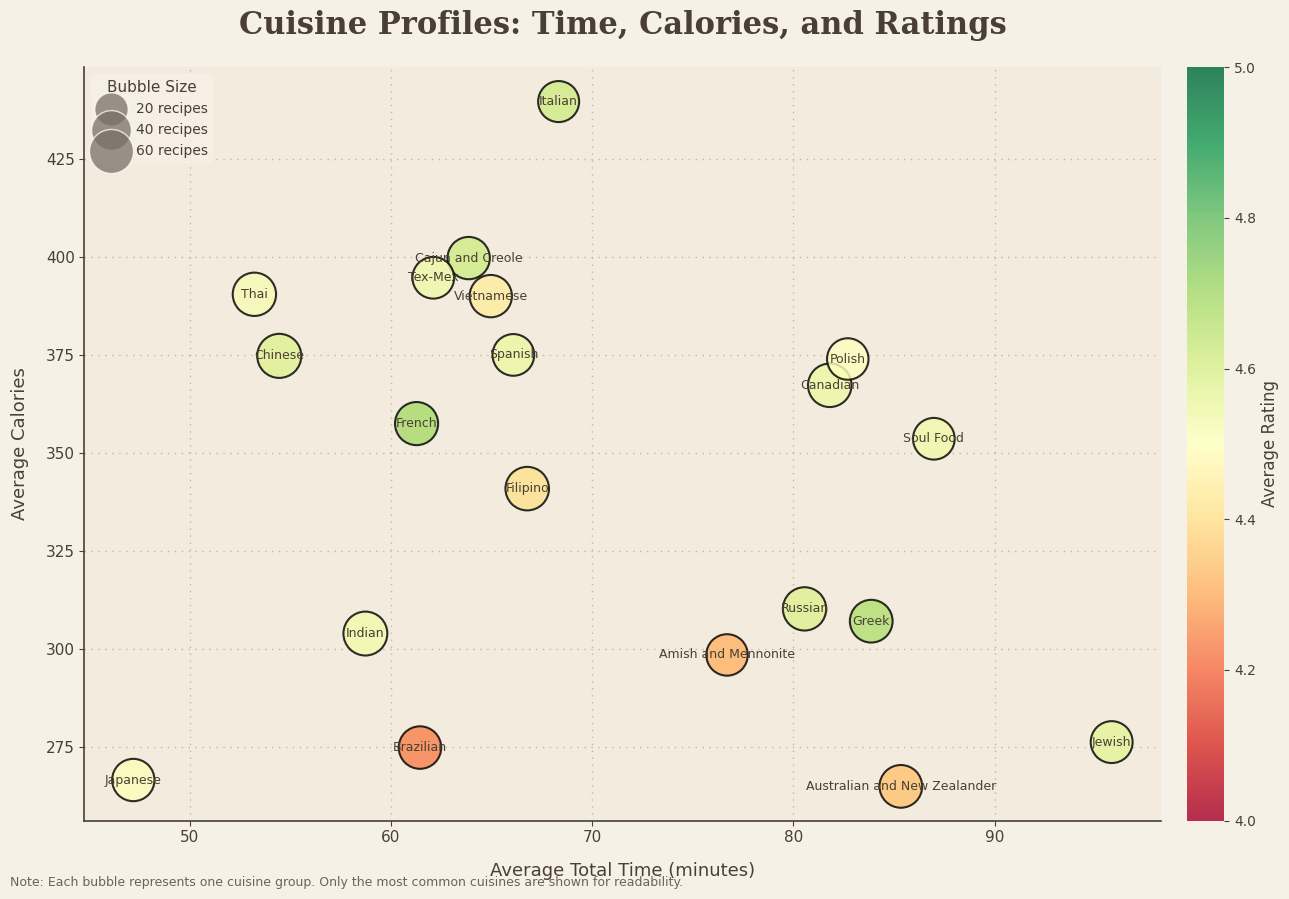

In [31]:
# Plot 2: Bubble plot of countries an their average rating against mean calories on x axis and mean total_time on y-axis
#this only includes the top 20 countries sorted by sample size 
country_bubble = (
    cuisines_cleaned
    .groupby('country', as_index=False)
    .agg(
        mean_rating=('avg_rating', 'mean'),
        mean_calories=('calories', 'mean'),
        mean_total_time=('total_time', 'mean'),
        n_recipes=('avg_rating', 'size')
    )
)

top_n = 20
country_bubble = country_bubble.sort_values('n_recipes', ascending=False).head(top_n).copy()

bg_color = '#F6F1E7'
panel_color = '#F3EBDD'
text_color = '#4A3F35'
grid_color = '#B8AA96'

bubble_sizes = np.sqrt(country_bubble['n_recipes']) * 130

fig, ax = plt.subplots(figsize=(14, 9), facecolor=bg_color)
ax.set_facecolor(panel_color)

scatter = ax.scatter(
    country_bubble['mean_total_time'],
    country_bubble['mean_calories'],
    s=bubble_sizes,
    c=country_bubble['mean_rating'],
    cmap='RdYlGn',
    vmin=4,
    vmax=5,
    alpha=0.82,
    edgecolors='black',
    linewidths=1.5,
    zorder=2
)

for _, row in country_bubble.iterrows():
    ax.text(
        row['mean_total_time'],
        row['mean_calories'],
        row['country'],
        fontsize=9,
        color=text_color,
        ha='center',
        va='center',
        zorder=4
    )

ax.set_title(
    'Cuisine Profiles: Time, Calories, and Ratings',
    fontsize=22,
    weight='bold',
    color=text_color,
    pad=24,
    family='serif'
)

ax.set_xlabel('Average Total Time (minutes)', fontsize=13, color=text_color, labelpad=12)
ax.set_ylabel('Average Calories', fontsize=13, color=text_color, labelpad=12)

ax.tick_params(axis='x', colors=text_color, labelsize=11)
ax.tick_params(axis='y', colors=text_color, labelsize=11)

# dotted grid like your example
ax.grid(True, linestyle=(0, (1, 4)), linewidth=1, color=grid_color, alpha=0.8)
ax.set_axisbelow(True)

# spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(text_color)
    ax.spines[spine].set_linewidth(1.2)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Average Rating', fontsize=12, color=text_color)
cbar.ax.tick_params(labelsize=10, colors=text_color)
cbar.outline.set_visible(False)

# choose example recipe counts
size_examples = [20, 40, 60]
handles = [
    plt.scatter([], [], s=np.sqrt(s) * 130, color='#7A7066', alpha=0.75, edgecolors='white')
    for s in size_examples
]
labels = [f'{s} recipes' for s in size_examples]

legend = ax.legend(
    handles, labels,
    title='Bubble Size',
    loc='upper left',
    frameon=True,
    facecolor=bg_color,
    edgecolor='none',
    fontsize=10,
    title_fontsize=11
)

plt.setp(legend.get_texts(), color=text_color)
plt.setp(legend.get_title(), color=text_color)

fig.text(
    0.01, 0.01,
    'Note: Each bubble represents one cuisine group. Only the most common cuisines are shown for readability.',
    fontsize=9,
    color='#6E6255'
)

plt.tight_layout()
plt.show()

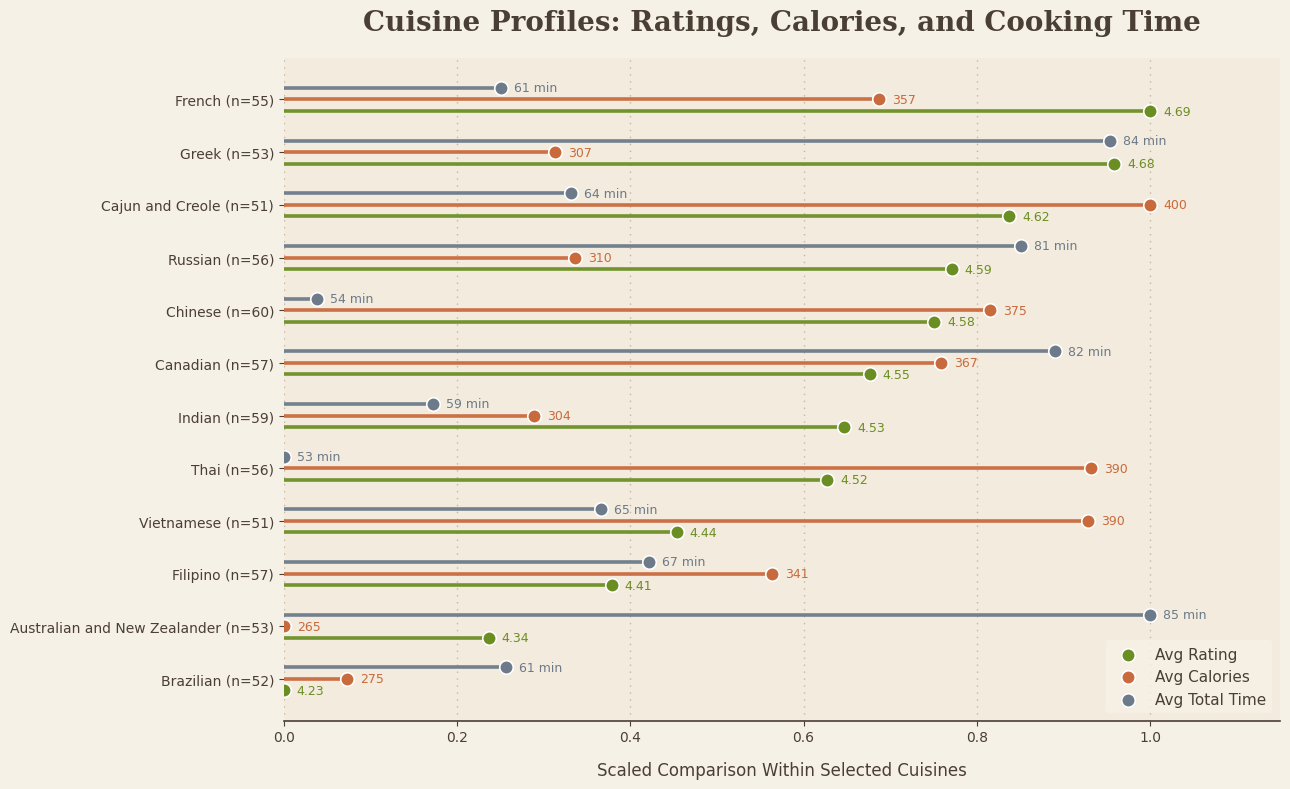

In [25]:
#plot 3: lollipop plot 
country_summary = (
    cuisines_cleaned
    .groupby('country', as_index=False)
    .agg(
        mean_rating=('avg_rating', 'mean'),
        mean_calories=('calories', 'mean'),
        mean_total_time=('total_time', 'mean'),
        n_recipes=('avg_rating', 'size')
    )
)

# Keep top countries by recipe count; do yall think 12 is enough or should we increase the count?
top_n = 12
country_summary = country_summary.sort_values('n_recipes', ascending=False).head(top_n).copy()

metrics = ['mean_rating', 'mean_calories', 'mean_total_time']

for col in metrics:
    min_val = country_summary[col].min()
    max_val = country_summary[col].max()
    country_summary[col + '_scaled'] = (country_summary[col] - min_val) / (max_val - min_val)

country_summary = country_summary.sort_values('mean_rating', ascending=True).reset_index(drop=True)
country_summary['label'] = country_summary['country'] + ' (n=' + country_summary['n_recipes'].astype(str) + ')'


bg_color = '#F6F1E7'
panel_color = '#F3EBDD'
text_color = '#4A3F35'
grid_color = '#B8AA96'
rating_color = '#6B8E23'
calories_color = '#C96A3D'
time_color = '#6C7A89'

fig, ax = plt.subplots(figsize=(13, 8), facecolor=bg_color)
ax.set_facecolor(panel_color)

y = np.arange(len(country_summary))

offset_rating = -0.22
offset_calories = 0.0
offset_time = 0.22

# Rating lollipops
ax.hlines(y + offset_rating, xmin=0, xmax=country_summary['mean_rating_scaled'],
          color=rating_color, linewidth=2.6, alpha=0.95)
ax.scatter(country_summary['mean_rating_scaled'], y + offset_rating,
           s=95, color=rating_color, edgecolor='white', linewidth=1.2,
           label='Avg Rating', zorder=3)

# Calories lollipops
ax.hlines(y + offset_calories, xmin=0, xmax=country_summary['mean_calories_scaled'],
          color=calories_color, linewidth=2.6, alpha=0.95)
ax.scatter(country_summary['mean_calories_scaled'], y + offset_calories,
           s=95, color=calories_color, edgecolor='white', linewidth=1.2,
           label='Avg Calories', zorder=3)

# Total time lollipops
ax.hlines(y + offset_time, xmin=0, xmax=country_summary['mean_total_time_scaled'],
          color=time_color, linewidth=2.6, alpha=0.95)
ax.scatter(country_summary['mean_total_time_scaled'], y + offset_time,
           s=95, color=time_color, edgecolor='white', linewidth=1.2,
           label='Avg Total Time', zorder=3)

# Add value labels
for i, row in country_summary.iterrows():
    ax.text(row['mean_rating_scaled'] + 0.015, i + offset_rating,
            f"{row['mean_rating']:.2f}",
            va='center', ha='left', fontsize=9, color=rating_color)
    
    ax.text(row['mean_calories_scaled'] + 0.015, i + offset_calories,
            f"{row['mean_calories']:.0f}",
            va='center', ha='left', fontsize=9, color=calories_color)
    
    ax.text(row['mean_total_time_scaled'] + 0.015, i + offset_time,
            f"{row['mean_total_time']:.0f} min",
            va='center', ha='left', fontsize=9, color=time_color)

# Formatting
ax.set_yticks(y)
ax.set_yticklabels(country_summary['label'], fontsize=10, color=text_color)

ax.set_xlim(0, 1.15)
ax.set_xlabel('Scaled Comparison Within Selected Cuisines', fontsize=12, color=text_color, labelpad=12)
ax.set_title('Cuisine Profiles: Ratings, Calories, and Cooking Time',
             fontsize=20, weight='bold', color=text_color, pad=20, family='serif')

# Grid and spines
ax.grid(axis='x', linestyle=(0, (1, 4)), linewidth=1, color=grid_color, alpha=0.8)
ax.tick_params(axis='x', colors=text_color)
ax.tick_params(axis='y', colors=text_color)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(text_color)
ax.spines['bottom'].set_linewidth(1.2)

# Legend
legend = ax.legend(
    loc='lower right',
    frameon=True,
    facecolor=bg_color,
    edgecolor='none',
    fontsize=11
)
for text in legend.get_texts():
    text.set_color(text_color)

plt.tight_layout()
plt.show()


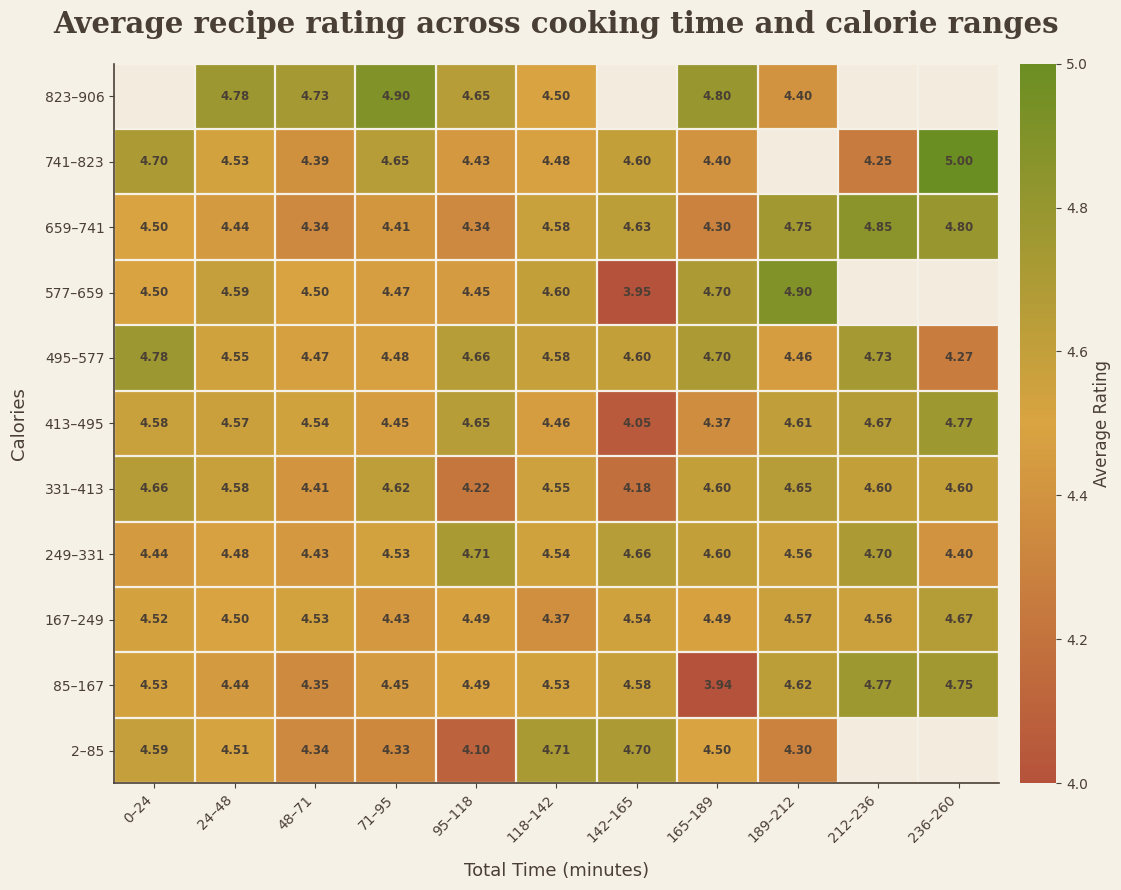

In [ ]:
#plot 4: no cuisine/country here; comparison between ratings against calories/cooking time 
from matplotlib.colors import LinearSegmentedColormap

heatmap_data = cuisines_cleaned[['total_time', 'calories', 'avg_rating']].copy()

x_bins = np.linspace(heatmap_data['total_time'].min(), heatmap_data['total_time'].max(), 12)
y_bins = np.linspace(heatmap_data['calories'].min(), heatmap_data['calories'].max(), 12)

heatmap_data['time_bin'] = pd.cut(heatmap_data['total_time'], bins=x_bins, include_lowest=True)
heatmap_data['calorie_bin'] = pd.cut(heatmap_data['calories'], bins=y_bins, include_lowest=True)
rating_grid = (
    heatmap_data
    .groupby(['calorie_bin', 'time_bin'])['avg_rating']
    .mean()
    .unstack()
)

# colormap
recipe_cmap = LinearSegmentedColormap.from_list(
    'recipe_rating',
    ['#B5523B', '#D9A441', '#6B8E23']
)

bg_color = '#F6F1E7'
panel_color = '#F3EBDD'
text_color = '#4A3F35'
grid_color = '#B8AA96'

fig, ax = plt.subplots(figsize=(12, 9), facecolor=bg_color)
ax.set_facecolor(panel_color)

im = ax.imshow(
    rating_grid,
    origin='lower',
    aspect='auto',
    cmap=recipe_cmap,
    vmin=4,
    vmax=5
)

x_labels = [
    f"{int(interval.left)}–{int(interval.right)}"
    for interval in rating_grid.columns
]
y_labels = [
    f"{int(interval.left)}–{int(interval.right)}"
    for interval in rating_grid.index
]

ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10, color=text_color)

ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=10, color=text_color)

ax.set_title(
    'Average recipe rating across cooking time and calorie ranges',
    fontsize=21,
    weight='bold',
    color=text_color,
    pad=22,
    family='serif'
)

ax.set_xlabel('Total Time (minutes)', fontsize=13, color=text_color, labelpad=12)
ax.set_ylabel('Calories', fontsize=13, color=text_color, labelpad=12)

for i in range(rating_grid.shape[0]):
    for j in range(rating_grid.shape[1]):
        value = rating_grid.iloc[i, j]
        if pd.notnull(value):
            ax.text(
                j, i, f"{value:.2f}",
                ha='center',
                va='center',
                fontsize=8.5,
                color='white' if value < 3.6 else text_color,
                weight='bold'
            )

ax.set_xticks(np.arange(-0.5, rating_grid.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, rating_grid.shape[0], 1), minor=True)
ax.grid(which='minor', color=bg_color, linestyle='-', linewidth=1.6)
ax.tick_params(which='minor', bottom=False, left=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color(text_color)
    ax.spines[spine].set_linewidth(1.2)

ax.tick_params(axis='x', colors=text_color)
ax.tick_params(axis='y', colors=text_color)

cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Average Rating', fontsize=12, color=text_color)
cbar.ax.tick_params(labelsize=10, colors=text_color)
cbar.outline.set_visible(False)


plt.tight_layout()
plt.show()